# Ridge Regression


6.1  Derive the weight update steps of stochastic gradient descent (SGD) for linear regression with L2 regularisation norm or a system of linear equations that uniquely determine the minimum of the regularised error function. Give this derivation with enough explanation in a markdown cell (ideally using Latex for readable math typesetting). The starting point is the definition of the regularised error function and the end result is either the weight update step for this function in (stochastic) gradient descent or a system of linear equations described in matrix/vector notation. In both cases, you have to derive the gradient as an intermediate step

$$ \text{This is the regularized error function for linear regression with L2 regularization } $$

$$E(w) = \frac{1}{2N} \sum_{i=1}^{N} (t_n - y(x_n,w))^2 + \frac{\lambda}{2} \|w\|^2 \text{ N = batch size}$$

$$ \text{To derive this function, we used partial derivatives on the function specifically the w(weight) of the function so it become}$$

$$\frac{\partial}{\partial w} E(w) = \frac{\partial}{\partial w}\frac{1}{2N} \sum_{i=1}^{N} (t_n - y(x_n,w))^2 + \frac{\lambda}{2} \|w\|^2$$

$$\text{According to the derivative criterion, we can assume that the gradient of the error function is equal to 0. The gradient is denoted as } \nabla E(w)\ \text{so we can write it}$$

$$
\begin{pmatrix}
\frac{\partial E}{\partial w_1} \\
\vdots \\
\frac{\partial E}{\partial w_n}
\end{pmatrix}
=
\begin{pmatrix}
0 \\
\vdots \\
0
\end{pmatrix}
$$

$$\text{Then we can derive the partial derivative of the function so that it become}$$

$$\frac{\partial}{\partial w} E(w) = \frac{1}{N} \sum_{i=1}^{N} (t_n - y(x_n,w)).x_n + \lambda \|w\|$$

$$\text{Rewriting the partial derivatives as dot and matrix product we get}$$

$$\nabla E(w) = -\frac{1}{N}(\tilde T - w . \tilde X) . \tilde X + \lambda W$$

$$\text{Simplifying the function}$$

$$\nabla E(w) = \frac{1}{N} \tilde X^T (w . \tilde X - \tilde T  )   + \lambda W$$

$$\text{Then defining the update rules for the weight for stochastic gradient descent we got}$$

$$ \mathbf{w}_\tau = \mathbf{w}_{\tau-1} - \eta \nabla E(\mathbf{w}_{\tau-1})$$

$$ \text{Updating the } \nabla E(w) \text{to } \nabla E(\mathbf{w}_{\tau-1}) \text{we got}$$

$$\nabla E(\mathbf{w}_{\tau-1}) = \frac{1}{N} \tilde X^T (\mathbf{w}_{\tau-1} . \tilde X - \tilde T  )   + \lambda \mathbf{w}_{\tau-1}$$

$$\text{Then we insert it to the equation to get the weight update steps for stochastic gradient descent}$$

$$ \mathbf{w}_\tau = \mathbf{w}_{\tau-1} - \eta(\frac{1}{N} \tilde X^T (\mathbf{w}_{\tau-1} . \tilde X - \tilde T  )   + \lambda \mathbf{w}_{\tau-1})$$

6.2 Using the analytically derived gradient from Step I, implement either a direct or a (stochastic) gradient descent algorithm for Ridge Regression

In [1]:
#Import the library for this question
import numpy as np

#Making the class for stochastic gradient descent algorithm for ridge regression
class SGDRidgeRegressor:
    #Initializing the init
    def __init__(self, alpha=0.2, batch_size=1, eta=0.01, tau_max=1000, epsilon=0.00001, random_state=None):
        self.eta = eta
        self.alpha = alpha
        self.tau_max = tau_max
        self.epsilon = epsilon
        self.random_state = random_state
        self.batch_size = batch_size

    #Intialize the fit function    
    def fit(self, x, y):
        #Initialize the random number to shuffle the data
        RNG = np.random.default_rng(self.random_state)
        #Storing the shape of the dataset
        n, p = x.shape
        #Initializing the array for the w
        self.w_ = np.zeros(shape=(self.tau_max+1, p))
        #Making the gradient descent for loop
        for tau in range(1, self.tau_max+1):
            #Initial w and the previous w
            w_old = self.w_[tau-1]
            #Randoming to select the datapoint across the batch
            idx = RNG.choice(n, size=self.batch_size, replace=True)
            #Selecting the x and y batch
            x_batch = x[idx]
            y_batch = y[idx].squeeze()
            #Function for the gradient descent
            grad = x_batch.T.dot(x_batch.dot(w_old)-y_batch)/self.batch_size + self.alpha*w_old
            #Updating the w
            self.w_[tau] = w_old - self.eta*grad
            #To terminate the for loop if the w is already small enough
            if np.linalg.norm(self.w_[tau]-w_old) < self.epsilon:
                break
        self.coef_ = self.w_[tau] 
        self.w_ = self.w_[:tau+1]
        return self
    #Function to predict the y
    def predict(self, x):
        return x.dot(self.coef_)

6.3.a Consider the ridge regression model for each in {10 10+9i/100,...,10 1 :0 i  100} by creating a pipeline of your implemented ridge regressor with a polynomial feature transformer with degree 5.

In [2]:
#Function to generate the artificial data
#Defining the formula
def f(x):
    return np.sin(5*np.pi*x)/(1+2*x)

#Defining the function to generate artifical data
def data(n, f, a, b, noise=0.1**0.5, random_state=None):
    #To randomize the data
    RNG = np.random.default_rng(random_state)
    #Generating x
    x = RNG.uniform(a, b, size=(n, 1))
    #Generating y
    y = f(x) + RNG.normal(0, noise, size=(n, 1))
    return x, y

6.3.b Fit each model at least ten times (resampling a training dataset of size 20 each time) for all choices of . To reduce the variance of the experiment make sure that for each repetition all models use the same training dataset (i.e., make the repetitions the outer loop and the choices of the inner loop, and sample only one training set per outer loop).

In [3]:
#Importing the library for this question
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.metrics import mean_squared_error

#Generating the array for the lambda
alpha_6_2 = np.geomspace(10**-10, 0.1, 101, endpoint=True)
#Initializing the reps
reps = 10

#Initialize the artificial test data
x_test, y_test = data(100000, f, -0.3, 0.3, random_state=79)

#Initializing the array for train and test result
train_result = np.zeros(shape=(len(alpha_6_2), reps))
test_result = np.zeros(shape=(len(alpha_6_2), reps))

#For loop to to fit the model 10 times and resampling it 20 times
for i in range(reps):
    #Produce the artificial the x and y train data and resampling it 20 times
    x_train, y_train = data(20, f, -0.3, 0.3, random_state=i)
    #For loop to fit the model
    for n,m in enumerate(alpha_6_2):
        #Making the pipeline for the Polynomial transformer 5 degree then fit it with SGD ridge regressor
        model = make_pipeline(PolynomialFeatures(5), SGDRidgeRegressor(alpha=m, batch_size=134, random_state=13))
        model.fit(x_train,y_train)

        #Saving the mean squared error for train and test result
        train_result[n,i] = mean_squared_error(y_train, model.predict(x_train))
        test_result[n,i] = mean_squared_error(y_test,model.predict(x_test))



6.3.c Create a plot of mean squared errors (use di↵erent colors for the training and testing errors), where the x-axis is log lambda and y-axis is the log mean squared error. Discuss, model complexity, and error rates, corresponding to underfitting and overfitting, by observing your plot.

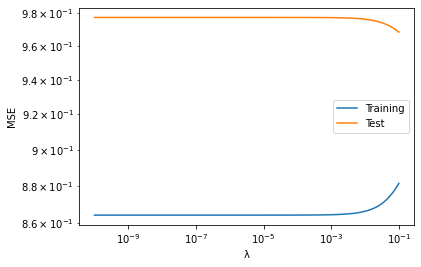

In [4]:
#Importing the library for this question
from matplotlib import pyplot as plt

#Plotting the mean squared error for test and training
plt.plot(alpha_6_2, train_result.mean(axis=1), label='Training')
plt.plot(alpha_6_2, test_result.mean(axis=1), label='Test')
plt.xscale('log')
plt.yscale('log')
plt.xlabel('λ')
plt.ylabel('MSE')
plt.legend()
plt.show()

Discuss, model complexity, and error rates, corresponding to underfitting and overfitting, by observing your plot.

$$\text{From the model we can see that the error rates start to converge for both training and test data with lambda above }(10^{-3}) \text{ to } (10{^-1}) $$
$$\text{With the model transformed with polynomial transformator to 5th degree, the model becames much more complex therefore prone to overfitting.}\\ \text{This is illustrated with low error for training and high error for test with low lambda value which is } (10^{-9})\text{ until approximately around } (10^{-3})$$ 
$$\text{With the introduction of Ridge Regression, the error function of the complex polynomial model is added with the regularization value which is } \lambda \mathbf{w} \\
\text{To penalize the complexity of the model, therefore reducing the complexity and solving the overfitting issue of the model}$$
$$\text{We can see from the graph that approximately after } (10^{-2}) \text{lambda value, the train error became higher and test error became lower signifying that}\\
\text{ the regularization has added the error function to reduce the model complexity therefore making the model much more general and applicable to a wider range of data}$$